## Compilación de históricos (Data/Historicos)

Los CSV del SGC vienen en dos formatos. El antiguo (época SEISAN, 1995 – feb 2018) trae `FECHA` y `HORA_UTC` separadas, magnitudes `Ml` y `Mw` en columnas propias y la ubicación por `DEPARTAMENTO`/`MUNICIPIO`. El nuevo (época SeisComP, mar 2018 – 2020) trae `FECHA - HORA UTC` combinada, una sola `MAGNITUD` con su `TIPO MAGNITUD` y la ubicación por `REGION`. Ambos se normalizan a un esquema único. Los 13.952 eventos de 2016 aparecen duplicados en `reporte2015_2016` y `reporte2017_2018`, así que se eliminan duplicados por (FECHA, LATITUD, LONGITUD).

El catálogo se compila completo (1995–2020), sin recortar aún a 2005–2020. El periodo previo actúa como zona de guarda temporal para el declustering: las réplicas de comienzos de 2005 necesitan encontrar su mainshock en el catálogo (el Mw 6.7 de Bahía Solano del 15-nov-2004, o los M 5.3 del 25 y 30-dic-2004). El recorte definitivo se aplica después de declusterizar, en la celda de Reasenberg.

In [1]:
from pathlib import Path
import pandas as pd 

DIR_HISTORICOS = Path("/home/jasonromeroia/Documents/personal/Tesis_MCIC/lgcp_inla_spde_sismos/Data/Historicos")

COLS_FORMATO_ANTIGUO = {
    "LATITUD (grados)": "LATITUD",
    "LONGITUD (grados)": "LONGITUD",
    "PROFUNDIDAD (Km)": "PROFUNDIDAD_KM",
    "# FASES": "NUM_FASES",
    "RMS (Seg)": "RMS_SEG",
    "GAP (grados)": "GAP_GRADOS",
    "ERROR LATITUD (Km)": "ERROR_LATITUD_KM",
    "ERROR LONGITUD (Km)": "ERROR_LONGITUD_KM",
    "ERROR PROFUNDIDAD (Km)": "ERROR_PROFUNDIDAD_KM",
}

COLS_FORMATO_NUEVO = {
    "LATITUD (°)": "LATITUD",
    "LONGITUD (°)": "LONGITUD",
    "PROF. (Km)": "PROFUNDIDAD_KM",
    "TIPO MAGNITUD": "TIPO_MAGNITUD",
    "FASES": "NUM_FASES",
    "RMS (Seg)": "RMS_SEG",
    "GAP (°)": "GAP_GRADOS",
    "ERROR LATITUD (Km)": "ERROR_LATITUD_KM",
    "ERROR LONGITUD (Km)": "ERROR_LONGITUD_KM",
    "ERROR PROFUNDIDAD (Km)": "ERROR_PROFUNDIDAD_KM",
}


def leer_historico(ruta):
    df = pd.read_csv(ruta)
    if "FECHA - HORA UTC" in df.columns:  # formato nuevo (SeisComP)
        df = df.rename(columns=COLS_FORMATO_NUEVO)
        df["FECHA"] = pd.to_datetime(df["FECHA - HORA UTC"])
        df = df.drop(columns=["FECHA - HORA UTC"])
    else:  # formato antiguo (SEISAN)
        df = df.rename(columns=COLS_FORMATO_ANTIGUO)
        df["FECHA"] = pd.to_datetime(df["FECHA"] + " " + df["HORA_UTC"])
        tiene_mw = df["MAGNITUD Mw"].notna()
        df["MAGNITUD"] = df["MAGNITUD Mw"].where(tiene_mw, df["MAGNITUD Ml"])
        df["TIPO_MAGNITUD"] = tiene_mw.map({True: "Mw", False: "Ml"})
        df = df.drop(columns=["MAGNITUD Ml", "MAGNITUD Mw", "HORA_UTC"])
    df["ARCHIVO"] = ruta.name
    return df


archivos = sorted(DIR_HISTORICOS.glob("*.csv"))
df_hist = pd.concat([leer_historico(f) for f in archivos], ignore_index=True)

n_antes = len(df_hist)
df_hist = (
    df_hist.sort_values("FECHA")
    .drop_duplicates(subset=["FECHA", "LATITUD", "LONGITUD"], keep="first")
    .reset_index(drop=True)
)
df_hist["YEAR"] = df_hist["FECHA"].dt.year

orden = [
    "FECHA", "YEAR", "LATITUD", "LONGITUD", "PROFUNDIDAD_KM",
    "MAGNITUD", "TIPO_MAGNITUD", "NUM_FASES", "RMS_SEG", "GAP_GRADOS",
    "ERROR_LATITUD_KM", "ERROR_LONGITUD_KM", "ERROR_PROFUNDIDAD_KM",
    "ESTADO", "DEPARTAMENTO", "MUNICIPIO", "REGION", "ARCHIVO",
]
df_hist = df_hist[orden]



print(f"{len(archivos)} archivos, {n_antes} filas leídas, {n_antes - len(df_hist)} duplicados eliminados")
print(f"Catálogo compilado: {len(df_hist)} eventos, {df_hist['FECHA'].min()} a {df_hist['FECHA'].max()}")
df_hist.head()

10 archivos, 254676 filas leídas, 14014 duplicados eliminados
Catálogo compilado: 240662 eventos, 1995-01-01 00:09:56 a 2020-12-31 23:55:06


,FECHA,YEAR,LATITUD,LONGITUD,PROFUNDIDAD_KM,MAGNITUD,TIPO_MAGNITUD,NUM_FASES,RMS_SEG,GAP_GRADOS,ERROR_LATITUD_KM,ERROR_LONGITUD_KM,ERROR_PROFUNDIDAD_KM,ESTADO,DEPARTAMENTO,MUNICIPIO,REGION,ARCHIVO
0,1995-01-01 00:09:56,1995,6.835,-72.943,150.0,3.1,Ml,8,0.5,315.0,4.9,7.4,5.5,Revisado,SANTANDER,CEPITA,NaN,reporte1995_2000_utf8.csv
1,1995-01-01 00:28:08,1995,6.816,-73.070,150.0,2.5,Ml,6,0.5,326.0,6.3,19.7,6.4,Revisado,SANTANDER,LOS_SANTOS,NaN,reporte1995_2000_utf8.csv
2,1995-01-01 06:39:37,1995,3.088,-76.276,46.8,2.2,Ml,5,2.8,218.0,99.9,99.9,99.9,Revisado,CAUCA,CORINTO,NaN,reporte1995_2000_utf8.csv
3,1995-01-01 08:29:07,1995,6.871,-73.127,150.0,3.8,Ml,10,0.8,310.0,9.9,14.0,8.6,Revisado,SANTANDER,LOS_SANTOS,NaN,reporte1995_2000_utf8.csv
4,1995-01-01 09:09:29,1995,2.333,-75.467,0.0,1.9,Ml,6,0.9,185.0,18.1,40.3,13.0,Revisado,HUILA,GIGANTE,NaN,reporte1995_2000_utf8.csv


In [2]:
df_hist.tail()

,FECHA,YEAR,LATITUD,LONGITUD,PROFUNDIDAD_KM,MAGNITUD,TIPO_MAGNITUD,NUM_FASES,RMS_SEG,GAP_GRADOS,ERROR_LATITUD_KM,ERROR_LONGITUD_KM,ERROR_PROFUNDIDAD_KM,ESTADO,DEPARTAMENTO,MUNICIPIO,REGION,ARCHIVO
240657,2020-12-31 23:04:57,2020,6.536,-74.605,6.66,1.5,MLr_vmm,25,0.4,90.0,0.707,0.707,1.80,manual,NaN,NaN,"Puerto Berrío - Antioquia, Colombia",reporte2020_2020_utf8.csv
240658,2020-12-31 23:28:36,2020,6.762,-73.124,136.33,1.8,MLr_3,10,0.7,111.0,5.866,7.294,10.04,manual,NaN,NaN,"Los Santos - Santander, Colombia",reporte2020_2020_utf8.csv
240659,2020-12-31 23:35:37,2020,5.303,-73.721,135.98,2.3,MLr_3,22,0.8,78.0,3.399,4.879,7.02,manual,NaN,NaN,"Lenguazaque - Cundinamarca, Colombia",reporte2020_2020_utf8.csv
240660,2020-12-31 23:39:56,2020,6.822,-73.154,151.70,1.9,MLr_3,14,0.3,112.0,1.344,1.344,2.10,manual,NaN,NaN,"Los Santos - Santander, Colombia",reporte2020_2020_utf8.csv
240661,2020-12-31 23:55:06,2020,7.706,-72.940,154.61,2.0,MLr_3,12,1.0,147.0,6.690,8.844,11.21,manual,NaN,NaN,"Salazar - Norte de Santander, Colombia",reporte2020_2020_utf8.csv


## Homogenización de magnitudes a Mw

Las ventanas espacio-temporales de los algoritmos de declustering (Gardner-Knopoff, Reasenberg) son función de la magnitud, y mezclar escalas introduce sesgo. El catálogo compilado mezcla tipos (`Ml` de la época SEISAN, `MLr` y variantes regionales de la época SeisComP, algunos `Mw` y `mb`), así que se estandariza todo a magnitud de momento con las relaciones oficiales del modelo nacional de amenaza sísmica, las mismas que adopta el Catálogo Sísmico Integrado (CSI) del SGC.

Para la familia de magnitud local del SGC (`Ml`, `MLr_*`, `MLv`, `M`) se usa (Arcila et al., 2020, §3.1.3, Tablas 9-11):

$$M_w = 0.958\,M_l + 0.1 \qquad (2.9 < M_l \le 6.1;\ \sigma = 0.50)$$

relación que el SGC deriva encadenando $m_b[M_{l,SGC}] = 1.0044\,M_l - 0.344$ (ISC-SGC, 1.599 eventos) con la relación $M_w$–$m_b$ de la Tabla 9. Para magnitud de ondas de cuerpo (`mb`, `mB`) se usa la bilineal con la forma funcional de Scordilis (2006):

$$M_w = 0.954\,m_b + 0.42 \;\; (3.6 < m_b \le 5.7); \qquad M_w = 1.433\,m_b - 2.35 \;\; (5.7 < m_b \le 7.7)$$

Los tipos que ya son momento (`Mw`, `Mw(mB)`, `Mw(Mwp)`, `Mwp`) se conservan sin transformación.

Las variantes `MLr_*` (calibración post-2018 en SeisComP) se tratan como familia Ml, porque la escala MLr del SGC fue calibrada para ser consistente con la Ml histórica (Londoño et al., 2020); el tipo `M`, de escala desconocida, se asimila también a esa familia. La relación Ml→Mw se aplica además fuera de su rango formal de validez, ya que la mayor parte del catálogo es Ml ≤ 2.9: es una extrapolación necesaria para no descartar microsismicidad antes del declustering, y las ventanas del algoritmo están dominadas por los eventos mayores, que sí caen dentro del rango válido.

Referencias:

- Arcila, M., García, J., Montejo, J., Eraso, J., Valcárcel, J., Mora, M., Viganò, D., Pagani, M. y Díaz, F. (2020). *Modelo nacional de amenaza sísmica para Colombia*. Servicio Geológico Colombiano - Fundación Global Earthquake Model. https://doi.org/10.32685/9789585279469 (§3.1.3, pp. 53-57)
- Montejo, J., Arcila, M. y Zornosa, J. (2023). Integrated Seismic Catalog for Colombia. *Boletín Geológico*, 50(1), 5-17. https://doi.org/10.32685/0538-3199.665 (§4.2.3)
- Scordilis, E. M. (2006). Empirical global relations converting MS and mb to moment magnitude. *Journal of Seismology*, 10, 225-236.
- Londoño, J. M., et al. (2020). Calibration of Local Magnitude Scale for Colombia. *Bulletin of the Seismological Society of America*, 110(4), 1971-1984.

In [3]:
import numpy as np

tipo = df_hist["TIPO_MAGNITUD"].astype(str).str.strip()

FAMILIA_MW = {"Mw", "Mw(mB)", "Mw(Mwp)", "Mwp"}
FAMILIA_MB = {"mb", "mB"}
es_mw = tipo.isin(FAMILIA_MW)
es_mb = tipo.isin(FAMILIA_MB)
es_ml = ~(es_mw | es_mb)  # Ml, ML, MLv, MLr_* y M

mag = df_hist["MAGNITUD"]
mw = pd.Series(np.nan, index=df_hist.index)

# Arcila et al. (2020): Ml lineal, mb bilineal con quiebre en mb = 5.7
mw[es_mw] = mag[es_mw]
mw[es_ml] = 0.958 * mag[es_ml] + 0.1
mb_lo = es_mb & (mag <= 5.7)
mb_hi = es_mb & (mag > 5.7)
mw[mb_lo] = 0.954 * mag[mb_lo] + 0.42
mw[mb_hi] = 1.433 * mag[mb_hi] - 2.35

df_hist["MAGNITUD_MW"] = mw.round(3)

fuera_rango = (es_ml & ((mag <= 2.9) | (mag > 6.1))).sum()
print(f"Conservados como Mw: {es_mw.sum()} | convertidos desde Ml/MLr: {es_ml.sum()} | desde mb: {es_mb.sum()}")
print(f"Eventos Ml fuera del rango de validez de la relacion (extrapolados): {fuera_rango}")
print(f"Rango Mw homogenizada: {df_hist['MAGNITUD_MW'].min():.2f} - {df_hist['MAGNITUD_MW'].max():.2f}")
df_hist[["MAGNITUD", "TIPO_MAGNITUD", "MAGNITUD_MW"]].sample(8, random_state=1)

Conservados como Mw: 4780 | convertidos desde Ml/MLr: 235873 | desde mb: 9
Eventos Ml fuera del rango de validez de la relacion (extrapolados): 218059
Rango Mw homogenizada: 0.10 - 7.10


,MAGNITUD,TIPO_MAGNITUD,MAGNITUD_MW
139188,2.0,Ml,2.016
68303,1.1,Ml,1.154
50956,2.5,Ml,2.495
57938,1.8,Ml,1.824
27019,2.8,Ml,2.782
1476,3.0,Ml,2.974
155874,1.5,Ml,1.537
214402,1.8,MLr_2,1.824


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt

DIR_FIG = Path("/home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images")
DIR_FIG.mkdir(parents=True, exist_ok=True)

def guardar_fig(fig, nombre, dpi=300):
    # sin título: va en el caption de LaTeX
    fig.savefig(DIR_FIG / nombre, dpi=dpi, bbox_inches="tight")
    print(f"[fig] {DIR_FIG / nombre}")

# Control de calidad

## Metodología

El catálogo trae, por evento, las métricas estándar de calidad de la localización hipocentral: número de fases usadas (`NUM_FASES`), residuo RMS del ajuste (`RMS_SEG`), brecha azimutal máxima entre estaciones (`GAP_GRADOS`), errores formales de localización (`ERROR_LATITUD_KM`, `ERROR_LONGITUD_KM`, `ERROR_PROFUNDIDAD_KM`) y el estado de revisión de la solución (`ESTADO`).

El control de calidad se hace en tres pasos. Primero un diagnóstico de valores faltantes, valores centinela (el formato antiguo SEISAN usa `99.9` como código de error desconocido), rangos físicos y evolución temporal de las métricas. Luego un marcado con banderas, donde cada criterio marca eventos sin eliminarlos todavía, para cuantificar cuánto aporta cada uno y cuánto se solapan. Por último la eliminación de los eventos marcados, excepto los de magnitud Mw >= 4.5.

La salvaguarda de eventos grandes es necesaria porque las ventanas del declustering (Reasenberg) se construyen alrededor de los mainshocks. Varios sismos mayores de los años 90 tienen métricas de red pobres, ya que la RSNC apenas iniciaba operación en 1993: el evento del 19-ene-1995 (Tauramena, M 6.6) tiene GAP 225° y error horizontal ~40 km, y el del 08-feb-1995 (Calima, M 6.6) tiene todas las métricas en cero. Son eventos reales y bien documentados, y eliminarlos dejaría huérfanas a sus réplicas, infiltrando clusters completos en el catálogo declusterizado. Sin salvaguarda, el filtro eliminaría 19 de los 73 eventos Mw >= 5.5 del catálogo.

Tres cosas no se filtran aquí. Las coordenadas, porque no hay ninguna físicamente inválida y los eventos lejanos (Pacífico abierto, Centroamérica) son reales: el recorte a la ventana continental de estudio se hace después, de forma espacial. La profundidad, porque el modelo LGCP es 2D y la profundidad no define la posición del punto; las profundidades negativas (hipocentro sobre el nivel del mar, convención SeisComP post-2018) y las fijadas (0 km, 150 km) se reportan como diagnóstico, no como motivo de eliminación. Y el criterio clásico GAP < 180°, que eliminaría ~38 % del catálogo, concentrado en fronteras, costas y años tempranos: un sesgo espacial y temporal inaceptable para un modelo de intensidad. Se usa en su lugar un umbral laxo de 300°, que solo remueve localizaciones esencialmente sin control azimutal.

Referencia: Havskov, J. y Ottemöller, L. (2010). *Routine Data Processing in Earthquake Seismology*. Springer. (Cap. 5: calidad de localización; mínimo teórico de 4 fases para resolver las 4 incógnitas del hipocentro $x, y, z, t$.)

In [5]:
df_hist.columns

Index(['FECHA', 'YEAR', 'LATITUD', 'LONGITUD', 'PROFUNDIDAD_KM', 'MAGNITUD',
       'TIPO_MAGNITUD', 'NUM_FASES', 'RMS_SEG', 'GAP_GRADOS',
       'ERROR_LATITUD_KM', 'ERROR_LONGITUD_KM', 'ERROR_PROFUNDIDAD_KM',
       'ESTADO', 'DEPARTAMENTO', 'MUNICIPIO', 'REGION', 'ARCHIVO',
       'MAGNITUD_MW'],
      dtype='object')

In [6]:
na = (
    df_hist.isna()
    .sum()
    .to_frame("Nulos")
)

na["Porcentaje"] = 100 * na["Nulos"] / len(df_hist)
na.sort_values("Porcentaje", ascending=False)

,Nulos,Porcentaje
REGION,168948,70.201361
DEPARTAMENTO,71714,29.798639
MUNICIPIO,71714,29.798639
ERROR_LONGITUD_KM,98,0.040721
ERROR_LATITUD_KM,98,0.040721
RMS_SEG,98,0.040721
GAP_GRADOS,98,0.040721
ERROR_PROFUNDIDAD_KM,98,0.040721
LATITUD,0,0.000000
FECHA,0,0.000000


In [7]:
cols_calidad = [
    "RMS_SEG",
    "GAP_GRADOS",
    "ERROR_LATITUD_KM",
    "ERROR_LONGITUD_KM",
    "ERROR_PROFUNDIDAD_KM",
]

df_hist[cols_calidad].isna().sum()

# Eventos con algún NA
na_calidad = df_hist[df_hist[cols_calidad].isna().any(axis=1)]

len(na_calidad)

98

In [8]:
na_calidad[cols_calidad].head()

,RMS_SEG,GAP_GRADOS,ERROR_LATITUD_KM,ERROR_LONGITUD_KM,ERROR_PROFUNDIDAD_KM
618,NaN,NaN,NaN,NaN,NaN
619,NaN,NaN,NaN,NaN,NaN
620,NaN,NaN,NaN,NaN,NaN
621,NaN,NaN,NaN,NaN,NaN
835,NaN,NaN,NaN,NaN,NaN


In [9]:
na_calidad["YEAR"].value_counts().sort_index()

YEAR
1995    96
2009     1
2013     1
Name: count, dtype: int64

In [10]:
cols = [
    "LATITUD",
    "LONGITUD",
    "PROFUNDIDAD_KM",
    "MAGNITUD_MW",
    "NUM_FASES",
    "RMS_SEG",
    "GAP_GRADOS",
    "ERROR_LATITUD_KM",
    "ERROR_LONGITUD_KM",
    "ERROR_PROFUNDIDAD_KM",
]

df_hist[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LATITUD,240662.0,6.206991,1.715890,-3.587,5.623,6.783,6.832,14.314
LONGITUD,240662.0,-74.062815,1.531124,-89.985,-74.673,-73.202,-73.123,-69.022
PROFUNDIDAD_KM,240662.0,95.176990,60.964431,-4.880,20.600,132.000,145.800,700.000
MAGNITUD_MW,240662.0,1.998553,0.657358,0.100,1.537,1.920,2.303,7.100
NUM_FASES,240662.0,10.834045,9.714614,0.000,5.000,8.000,12.000,101.000
RMS_SEG,240564.0,0.454042,0.233748,0.000,0.300,0.400,0.500,9.400
GAP_GRADOS,240564.0,163.867096,60.142781,0.000,124.000,154.000,200.000,360.000
ERROR_LATITUD_KM,240564.0,5.023927,6.384467,0.000,2.263,3.700,5.700,99.900
ERROR_LONGITUD_KM,240564.0,6.919007,8.551853,0.000,2.400,4.500,8.200,99.900
ERROR_PROFUNDIDAD_KM,240564.0,8.663553,10.413118,0.000,4.000,6.400,9.400,641.500


In [11]:
df_hist["PROFUNDIDAD_KM"].describe()

count    240662.000000
mean         95.176990
std          60.964431
min          -4.880000
25%          20.600000
50%         132.000000
75%         145.800000
max         700.000000
Name: PROFUNDIDAD_KM, dtype: float64

In [12]:
df_hist["RMS_SEG"].describe()

count    240564.000000
mean          0.454042
std           0.233748
min           0.000000
25%           0.300000
50%           0.400000
75%           0.500000
max           9.400000
Name: RMS_SEG, dtype: float64

<Axes: >

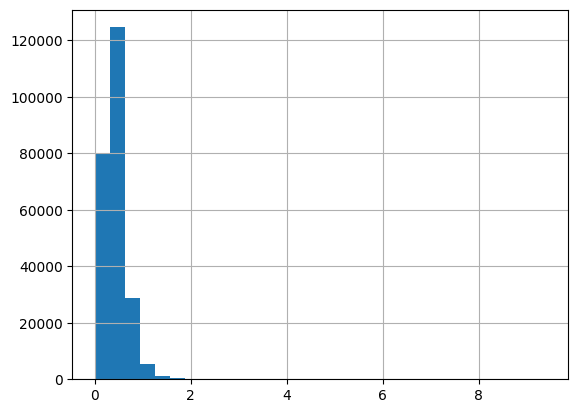

In [13]:
df_hist["RMS_SEG"].hist(bins=30)

In [14]:
df_hist["NUM_FASES"].describe()

count    240662.000000
mean         10.834045
std           9.714614
min           0.000000
25%           5.000000
50%           8.000000
75%          12.000000
max         101.000000
Name: NUM_FASES, dtype: float64

In [15]:
import numpy as np

df_hist["ERROR_HORIZONTAL_KM"] = np.sqrt(
    df_hist["ERROR_LATITUD_KM"]**2 +
    df_hist["ERROR_LONGITUD_KM"]**2
)

In [16]:
df_hist["ERROR_HORIZONTAL_KM"].describe()

count    240564.000000
mean          8.831906
std          10.440571
min           0.000000
25%           3.400000
50%           6.087693
75%          10.420173
max         141.279935
Name: ERROR_HORIZONTAL_KM, dtype: float64

<Axes: >

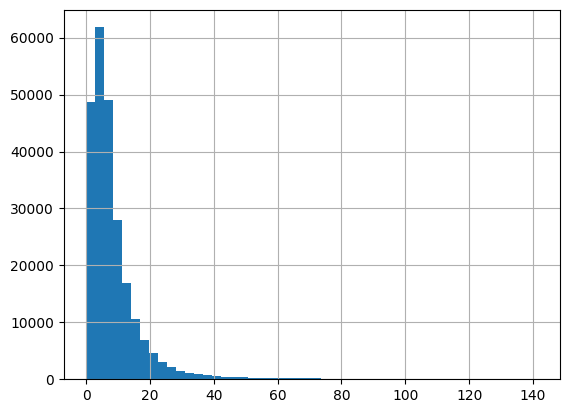

In [17]:
df_hist["ERROR_HORIZONTAL_KM"].hist(bins=50)

<Axes: xlabel='YEAR'>

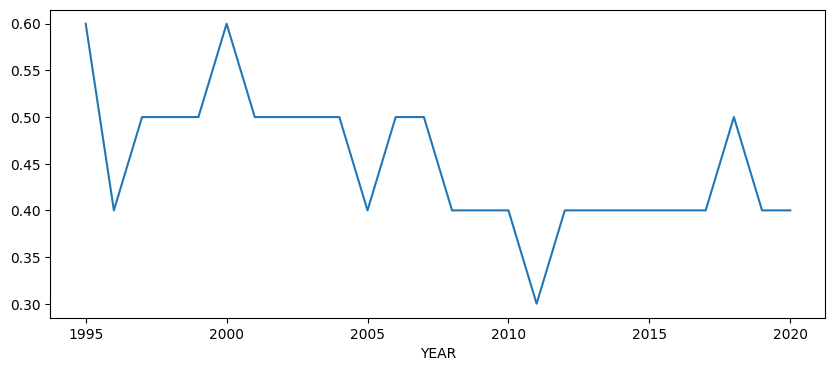

In [18]:
df_hist.groupby("YEAR")["RMS_SEG"].median().plot(figsize=(10,4))

<Axes: xlabel='YEAR'>

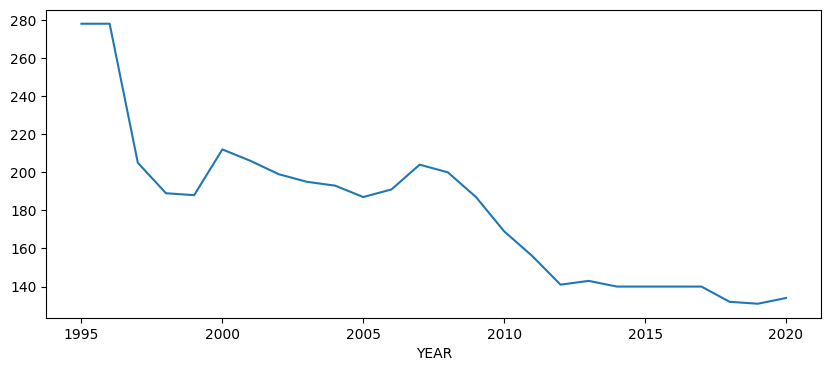

In [19]:
df_hist.groupby("YEAR")["GAP_GRADOS"].median().plot(figsize=(10,4))

<Axes: xlabel='YEAR'>

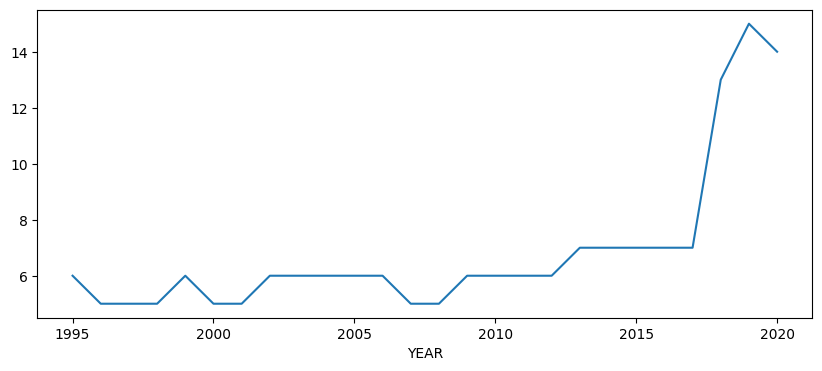

In [20]:
df_hist.groupby("YEAR")["NUM_FASES"].median().plot(figsize=(10,4))

[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/qc_metricas_anuales.png


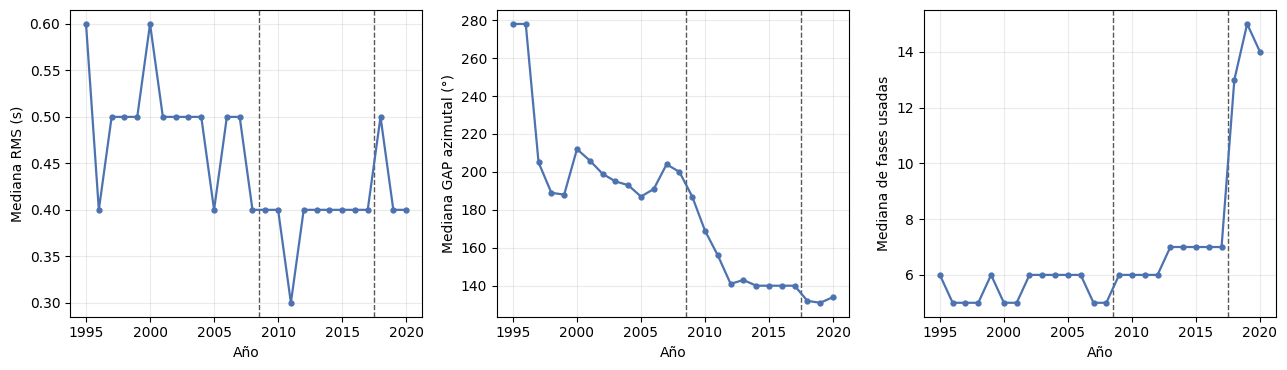

In [21]:
met = df_hist.groupby("YEAR")[["RMS_SEG", "GAP_GRADOS", "NUM_FASES"]].median()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
paneles = [("RMS_SEG", "Mediana RMS (s)"),
           ("GAP_GRADOS", "Mediana GAP azimutal (°)"),
           ("NUM_FASES", "Mediana de fases usadas")]
for ax, (colu, lbl) in zip(axes, paneles):
    ax.plot(met.index, met[colu], marker="o", ms=3.5, lw=1.6, color="#4C72B0", zorder=3)
    for xb in (2008.5, 2017.5):
        ax.axvline(xb, color="0.35", ls="--", lw=1, zorder=2)
    ax.set_xlabel("Año")
    ax.set_ylabel(lbl)
    ax.grid(alpha=0.25, zorder=1)
fig.tight_layout()
guardar_fig(fig, "qc_metricas_anuales.png")
plt.show()

In [22]:
df_hist[[
    "PROFUNDIDAD_KM",
    "MAGNITUD_MW",
    "NUM_FASES",
    "RMS_SEG",
    "GAP_GRADOS",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
PROFUNDIDAD_KM,240662.0,95.176990,60.964431,-4.88,20.600,132.00,145.800,700.0
MAGNITUD_MW,240662.0,1.998553,0.657358,0.10,1.537,1.92,2.303,7.1
NUM_FASES,240662.0,10.834045,9.714614,0.00,5.000,8.00,12.000,101.0
RMS_SEG,240564.0,0.454042,0.233748,0.00,0.300,0.40,0.500,9.4
GAP_GRADOS,240564.0,163.867096,60.142781,0.00,124.000,154.00,200.000,360.0


In [23]:
df_hist[df_hist["PROFUNDIDAD_KM"] < 0].shape

(2775, 20)

In [24]:
df_hist.loc[df_hist["PROFUNDIDAD_KM"] < 0,
            ["FECHA","LATITUD","LONGITUD","PROFUNDIDAD_KM","MAGNITUD_MW"]]

,FECHA,LATITUD,LONGITUD,PROFUNDIDAD_KM,MAGNITUD_MW
169168,2018-03-04 21:16:36,2.055,-74.266,-1.17,2.016
169233,2018-03-05 14:57:11,4.927,-75.653,-1.45,2.974
169235,2018-03-05 15:18:04,6.434,-76.733,-1.29,1.729
169265,2018-03-06 06:02:35,5.704,-73.011,-0.66,1.824
169271,2018-03-06 07:40:11,6.164,-73.961,-1.94,1.154
...,...,...,...,...,...
240423,2020-12-28 23:52:07,6.426,-73.692,-0.41,1.824
240455,2020-12-29 07:07:38,6.205,-72.102,-1.67,2.782
240481,2020-12-29 17:14:54,5.941,-74.919,-0.05,1.824
240579,2020-12-31 05:04:33,3.274,-78.044,-0.01,1.633


## Evolución temporal del catálogo: etapas de la red

Mc no es constante: depende de la densidad y la sensibilidad de la red, así que antes de estimarla conviene ver cómo cambia el catálogo en el tiempo. Se calculan por año, sobre el catálogo crudo, el número de eventos registrados (cuánto detecta la red), la mediana de Mw (dónde está el grueso de la distribución de magnitudes) y el percentil 5 % de Mw, que aproxima el piso de detección y baja cuando la red mejora.

Las tres señales cuentan la misma historia. El quiebre de 2008→2009 es nítido en todas —los eventos se duplican y las magnitudes caen— y coincide con la densificación de la Red Sismológica Nacional de Colombia. El límite de 2018, en cambio, es un salto en el conteo pero no en la magnitud: la mediana y el percentil 5 % ya están estabilizados desde ~2016, así que se justifica mejor como frontera instrumental y de procesamiento (migración SEISAN→SeisComP en marzo de 2018, que además cambia el tipo de magnitud a MLr) que como un nuevo descenso de Mc.

[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/etapas_red_evidencia.png


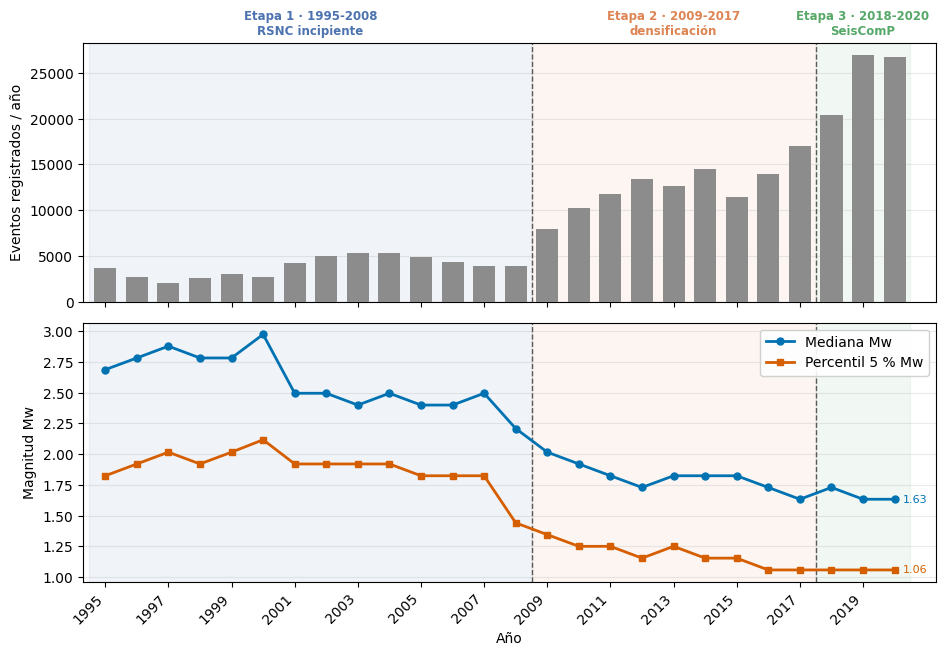

In [25]:
import matplotlib.pyplot as plt

g       = df_hist.groupby("YEAR")["MAGNITUD_MW"]
anios   = g.median().index.values
n_ev    = df_hist.groupby("YEAR").size().values
med_mw  = g.median().values
p5_mw   = g.quantile(0.05).values

ETAPAS = [
    (1995, 2008, "Etapa 1 · 1995-2008\nRSNC incipiente", "#4C72B0"),
    (2009, 2017, "Etapa 2 · 2009-2017\ndensificación",   "#DD8452"),
    (2018, 2020, "Etapa 3 · 2018-2020\nSeisComP",        "#55A868"),
]
AZUL, ROJO, GRIS = "#0072B2", "#D55E00", "#8C8C8C"

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

for a0, a1, _, col in ETAPAS:
    for ax in (ax1, ax2):
        ax.axvspan(a0 - 0.5, a1 + 0.5, color=col, alpha=0.08, zorder=0)

ax1.bar(anios, n_ev, color=GRIS, width=0.7, zorder=3)
ax1.set_ylabel("Eventos registrados / año")
for a0, a1, txt, col in ETAPAS:
    ax1.text((a0 + a1) / 2, ax1.get_ylim()[1] * 1.02, txt, ha="center", va="bottom",
             fontsize=8.5, color=col, weight="bold")
ax1.grid(axis="y", alpha=0.25, zorder=1)

ax2.plot(anios, med_mw, marker="o", ms=5, lw=2, color=AZUL, label="Mediana Mw", zorder=3)
ax2.plot(anios, p5_mw,  marker="s", ms=4, lw=2, color=ROJO, label="Percentil 5 % Mw", zorder=3)
ax2.set_ylabel("Magnitud Mw")
ax2.set_xlabel("Año")
ax2.grid(axis="y", alpha=0.25, zorder=1)
ax2.legend(loc="upper right", framealpha=0.9)
ax2.annotate(f"{med_mw[-1]:.2f}", (anios[-1], med_mw[-1]), textcoords="offset points",
             xytext=(6, 0), color=AZUL, fontsize=8, va="center")
ax2.annotate(f"{p5_mw[-1]:.2f}", (anios[-1], p5_mw[-1]), textcoords="offset points",
             xytext=(6, 0), color=ROJO, fontsize=8, va="center")

for xb in (2008.5, 2017.5):
    for ax in (ax1, ax2):
        ax.axvline(xb, color="0.35", ls="--", lw=1, zorder=2)

ax2.set_xlim(1994.3, 2021.3)
ax2.set_xticks(range(1995, 2021, 2))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
guardar_fig(fig, "etapas_red_evidencia.png")
plt.show()

In [26]:
rms = df_hist.groupby("YEAR")["RMS_SEG"].median()

## Diagnóstico consolidado

Antes de marcar nada se revisa el estado bruto de cada métrica: cuántos eventos tienen valores centinela (`99.9` en errores), valores nulos o valores fuera de rango físico. El diagnóstico calibra los umbrales, no elimina.

In [27]:
# El formato antiguo usa 99.9 como centinela de error desconocido
SENTINELA = 99.9
COLS_ERROR = ["ERROR_LATITUD_KM", "ERROR_LONGITUD_KM", "ERROR_PROFUNDIDAD_KM"]

for c in COLS_ERROR:
    n_cent = (df_hist[c] >= SENTINELA).sum()
    print(f"{c}: {n_cent} valores centinela (>= {SENTINELA})")

df_hist[COLS_ERROR] = df_hist[COLS_ERROR].where(df_hist[COLS_ERROR] < SENTINELA)

df_hist["ERROR_HORIZONTAL_KM"] = np.sqrt(
    df_hist["ERROR_LATITUD_KM"] ** 2 + df_hist["ERROR_LONGITUD_KM"] ** 2
)

ERROR_LATITUD_KM: 115 valores centinela (>= 99.9)
ERROR_LONGITUD_KM: 97 valores centinela (>= 99.9)
ERROR_PROFUNDIDAD_KM: 726 valores centinela (>= 99.9)


In [28]:
diag = df_hist[["NUM_FASES", "RMS_SEG", "GAP_GRADOS",
                "ERROR_HORIZONTAL_KM", "ERROR_PROFUNDIDAD_KM"]].describe(
    percentiles=[.05, .25, .5, .75, .95, .99]
).T
diag

,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
NUM_FASES,240662.0,10.834045,9.714614,0.0,4.000000,5.000000,8.000000,12.000000,30.000000,53.000000,101.000000
RMS_SEG,240564.0,0.454042,0.233748,0.0,0.200000,0.300000,0.400000,0.500000,0.900000,1.200000,9.400000
GAP_GRADOS,240564.0,163.867096,60.142781,0.0,70.000000,124.000000,154.000000,200.000000,281.000000,314.000000,360.000000
ERROR_HORIZONTAL_KM,240421.0,8.761470,10.028248,0.0,1.400071,3.399769,6.087693,10.406248,24.063458,53.382038,137.130339
ERROR_PROFUNDIDAD_KM,239838.0,8.385092,9.046894,0.0,1.600000,3.900000,6.400000,9.300000,21.600000,51.900000,99.800000


## Marcado de eventos (flags)

Cada criterio produce una columna booleana `FLAG_*`. Ningún evento se elimina en este paso: se cuantifica cuántos marca cada criterio y cuánto se solapan.

| Flag | Criterio | Justificación |
|------|----------|---------------|
| `FLAG_NA` | Alguna métrica de calidad nula | Sin control de calidad reportado |
| `FLAG_FASES` | `NUM_FASES < 4` | Menos de las 4 fases mínimas para resolver el hipocentro |
| `FLAG_RMS` | `RMS_SEG > 1.5` | Residuo de tiempos de llegada anómalamente alto |
| `FLAG_GAP` | `GAP_GRADOS > 300` | Cobertura azimutal casi nula (umbral laxo, ver metodología) |
| `FLAG_ERRH` | `ERROR_HORIZONTAL_KM > 30` o nulo/centinela | Localización horizontal muy incierta para un modelo espacial |

In [29]:
COLS_CALIDAD = ["RMS_SEG", "GAP_GRADOS", "ERROR_LATITUD_KM",
                "ERROR_LONGITUD_KM", "ERROR_PROFUNDIDAD_KM"]

df_hist["FLAG_NA"]    = df_hist[COLS_CALIDAD].isna().any(axis=1)
df_hist["FLAG_FASES"] = df_hist["NUM_FASES"] < 4
df_hist["FLAG_RMS"]   = df_hist["RMS_SEG"] > 1.5
df_hist["FLAG_GAP"]   = df_hist["GAP_GRADOS"] > 300
df_hist["FLAG_ERRH"]  = df_hist["ERROR_HORIZONTAL_KM"].isna() | (df_hist["ERROR_HORIZONTAL_KM"] > 30)

FLAGS = ["FLAG_NA", "FLAG_FASES", "FLAG_RMS", "FLAG_GAP", "FLAG_ERRH"]

resumen = pd.DataFrame({
    "eventos_marcados": [df_hist[f].sum() for f in FLAGS],
    "porcentaje": [round(100 * df_hist[f].mean(), 2) for f in FLAGS],
}, index=FLAGS)
df_hist["FLAG_ANY"] = df_hist[FLAGS].any(axis=1)
resumen.loc["FLAG_ANY (union)"] = [df_hist["FLAG_ANY"].sum(), round(100 * df_hist["FLAG_ANY"].mean(), 2)]
resumen

,eventos_marcados,porcentaje
FLAG_NA,843.0,0.35
FLAG_FASES,2027.0,0.84
FLAG_RMS,542.0,0.23
FLAG_GAP,5476.0,2.28
FLAG_ERRH,7860.0,3.27
FLAG_ANY (union),13689.0,5.69


In [30]:
combos = (
    df_hist.loc[df_hist["FLAG_ANY"], FLAGS]
    .value_counts()
    .head(10)
    .rename("eventos")
    .to_frame()
)
combos

eventos
FLAG_NA FLAG_FASES FLAG_RMS FLAG_GAP FLAG_ERRH         
False   False      False    False    True          5617
                            True     False         3932
        True       False    False    False         1160
        False      False    True     True           980
        True       False    False    True           330
        False      True     False    False          253
        True       False    True     False          232
True    False      False    False    True           231
False   False      True     False    True           212
True    False      False    False    False          188

## Eliminación con salvaguarda de eventos grandes

Se eliminan los eventos marcados por cualquier flag, excepto los de Mw >= 4.5. El corte de retención se reporta por año para verificar que no introduce un sesgo temporal severo; los años tempranos, con red incipiente, pierden más, lo que es esperado y aceptable porque el modelo espacio-temporal se ajusta desde 2005.

In [31]:
MW_SALVAGUARDA = 4.5

a_eliminar = df_hist["FLAG_ANY"] & (df_hist["MAGNITUD_MW"] < MW_SALVAGUARDA)

n0 = len(df_hist)
n_salvados = (df_hist["FLAG_ANY"] & (df_hist["MAGNITUD_MW"] >= MW_SALVAGUARDA)).sum()

df_qc = df_hist.loc[~a_eliminar].reset_index(drop=True)

print(f"Catálogo previo:    {n0} eventos")
print(f"Eliminados por QC:  {a_eliminar.sum()} ({100*a_eliminar.mean():.2f}%)")
print(f"Salvados (Mw>={MW_SALVAGUARDA}): {n_salvados} eventos grandes con métricas pobres se conservan")
print(f"Catálogo tras QC:   {len(df_qc)} eventos")

Catálogo previo:    240662 eventos
Eliminados por QC:  13543 (5.63%)
Salvados (Mw>=4.5): 146 eventos grandes con métricas pobres se conservan
Catálogo tras QC:   227119 eventos


In [32]:
retencion = pd.DataFrame({
    "n_antes": df_hist.groupby("YEAR").size(),
    "n_despues": df_qc.groupby("YEAR").size(),
}).fillna(0).astype(int)
retencion["retenido_%"] = (100 * retencion["n_despues"] / retencion["n_antes"]).round(1)
retencion

,n_antes,n_despues,retenido_%
YEAR,,,
1995,3669,2271,61.9
1996,2709,1494,55.1
1997,2007,1474,73.4
1998,2593,2096,80.8
1999,3008,2510,83.4
2000,2762,2076,75.2
2001,4212,3272,77.7
2002,4967,3843,77.4
2003,5350,4292,80.2


In [33]:
grandes_antes = (df_hist["MAGNITUD_MW"] >= 5.5).sum()
grandes_despues = (df_qc["MAGNITUD_MW"] >= 5.5).sum()
print(f"Eventos Mw>=5.5: {grandes_antes} antes  ->  {grandes_despues} después (deben coincidir)")
assert grandes_antes == grandes_despues, "Se perdio un evento grande: revisar la salvaguarda"

df_qc = df_qc.drop(columns=FLAGS + ["FLAG_ANY"])
print(f"\nColumnas finales: {list(df_qc.columns)}")
df_qc.head()

Eventos Mw>=5.5: 73 antes  ->  73 después (deben coincidir)

Columnas finales: ['FECHA', 'YEAR', 'LATITUD', 'LONGITUD', 'PROFUNDIDAD_KM', 'MAGNITUD', 'TIPO_MAGNITUD', 'NUM_FASES', 'RMS_SEG', 'GAP_GRADOS', 'ERROR_LATITUD_KM', 'ERROR_LONGITUD_KM', 'ERROR_PROFUNDIDAD_KM', 'ESTADO', 'DEPARTAMENTO', 'MUNICIPIO', 'REGION', 'ARCHIVO', 'MAGNITUD_MW', 'ERROR_HORIZONTAL_KM']


,FECHA,YEAR,LATITUD,LONGITUD,PROFUNDIDAD_KM,MAGNITUD,TIPO_MAGNITUD,NUM_FASES,RMS_SEG,GAP_GRADOS,ERROR_LATITUD_KM,ERROR_LONGITUD_KM,ERROR_PROFUNDIDAD_KM,ESTADO,DEPARTAMENTO,MUNICIPIO,REGION,ARCHIVO,MAGNITUD_MW,ERROR_HORIZONTAL_KM
0,1995-01-02 03:27:59,1995,6.645,-74.636,27.6,2.3,Ml,7,0.4,248.0,10.5,7.7,20.3,Revisado,ANTIOQUIA,MACEO,NaN,reporte1995_2000_utf8.csv,2.303,13.020753
1,1995-01-02 06:16:44,1995,5.595,-74.180,0.0,1.9,Ml,8,0.8,159.0,8.1,10.1,23.3,Revisado,BOYACA,OTANCHE,NaN,reporte1995_2000_utf8.csv,1.920,12.946814
2,1995-01-02 10:38:21,1995,6.687,-73.935,0.0,3.5,Ml,9,0.6,193.0,8.3,9.6,19.1,Revisado,SANTANDER,PUERTO_PARRA,NaN,reporte1995_2000_utf8.csv,3.453,12.690548
3,1995-01-02 22:33:25,1995,5.063,-75.503,138.2,4.5,Ml,9,1.0,112.0,11.3,9.4,51.5,Revisado,CALDAS,MANIZALES,NaN,reporte1995_2000_utf8.csv,4.411,14.698639
4,1995-01-03 07:31:31,1995,6.757,-73.265,150.0,3.9,Ml,10,0.8,246.0,6.5,14.9,8.4,Revisado,SANTANDER,ZAPATOCA,NaN,reporte1995_2000_utf8.csv,3.836,16.256076


# Magnitud de completitud Mc por etapa

Se estima Mc de forma independiente para las tres etapas de red (1995–2008, 2009–2017, 2018–2020), comparando tres métodos nativos de SeismoStats: MAXC (Maximum Curvature, Wiemer & Wyss 2000), que toma el pico del FMD y subestima Mc, por lo que lleva la corrección estándar +0.2; KS (distancia de Kolmogorov–Smirnov al ajuste GR, Clauset et al. 2009 / Mizrahi et al. 2021), sustituto moderno del clásico GFT; y b-stability (estabilidad del b-value, Cao & Gao 2002).

Todo se trabaja sobre la magnitud homogenizada `MAGNITUD_MW`. El único cuidado es el ancho de bin: homogenizar a Mw multiplica por 0.958, así que el paso efectivo de la malla no es 0.1 sino 0.0958. Se usa ese `delta_m` para no crear un FMD en dientes de sierra; redondear a 0.1 corre el pico de MAXC unas 0.3–0.4 unidades hacia abajo y daría una Mc falsamente baja.

La regla de adopción se fija de antemano, con MAXC como método primario. Sobre este catálogo KS y b-stability resultan inestables: con 40k–110k eventos por etapa, los tests basados en la ley GR se vuelven hipersensibles y sus estimaciones se van al borde del rango probado. MAXC es estable (σ bootstrap 0.02–0.07) y físicamente consistente, con Mc bajando conforme la red se densifica, así que se adopta MAXC (+0.2) como valor operativo y se reportan KS y b-stability solo como verificación cruzada, marcando cuándo tocan el borde. Es la recomendación de Mignan & Woessner (2012) para catálogos grandes; la incertidumbre de MAXC se cuantifica por bootstrap (Woessner & Wiemer 2005).

In [34]:
import io, contextlib, warnings
import numpy as np
from seismostats.analysis import (estimate_mc_maxc, estimate_mc_ks,
                                  estimate_mc_b_stability, estimate_b)
from seismostats.utils import bin_to_precision

DELTA_M      = 0.0958                                   # paso efectivo tras homogenizar (0.1*0.958)
MCS_TEST     = np.round(np.arange(0.5, 3.3, DELTA_M), 3)
KS_SUBSAMPLE = 20_000                                   # tope para el test KS
N_BOOT       = 300                                      # remuestreos bootstrap para sigma(MAXC)
SEED         = 0
ETAPAS = [("1995-2008", 1995, 2008, "#4C72B0"),
          ("2009-2017", 2009, 2017, "#DD8452"),
          ("2018-2020", 2018, 2020, "#55A868")]

def _silencio():
    return contextlib.redirect_stdout(io.StringIO())

def magnitudes_etapa(a0, a1):
    sel = df_qc["YEAR"].between(a0, a1)
    return bin_to_precision(df_qc.loc[sel, "MAGNITUD_MW"].dropna().to_numpy(), DELTA_M)

def maxc_bootstrap(m):
    with _silencio(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mc, _ = estimate_mc_maxc(m, fmd_bin=DELTA_M)
        rng = np.random.default_rng(SEED)
        boot = [estimate_mc_maxc(rng.choice(m, len(m), replace=True), fmd_bin=DELTA_M)[0]
                for _ in range(N_BOOT)]
    return round(mc, 2), round(float(np.std(boot)), 2), np.asarray(boot)

def crosscheck(m):
    with _silencio(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        rng = np.random.default_rng(SEED)
        m_ks = m if len(m) <= KS_SUBSAMPLE else rng.choice(m, KS_SUBSAMPLE, replace=False)
        mc_ks, _ = estimate_mc_ks(m_ks, delta_m=DELTA_M, mcs_test=MCS_TEST, n=200)
        mc_bs, _ = estimate_mc_b_stability(m, delta_m=DELTA_M, mcs_test=MCS_TEST)
    def etiqueta(mc):
        if mc is None or mc != mc:      return "no converge"
        if mc >= MCS_TEST[-1] - 1e-6:   return f"{mc:.2f} (borde: no fiable)"
        return f"{mc:.2f}"
    return etiqueta(mc_ks), etiqueta(mc_bs)

filas, mc_adoptada, sigma_maxc, boot_maxc = [], {}, {}, {}
for nombre, a0, a1, _ in ETAPAS:
    m = magnitudes_etapa(a0, a1)
    mc_mw, sigma, boot = maxc_bootstrap(m)
    ks_lbl, bs_lbl = crosscheck(m)
    mc_adoptada[nombre] = mc_mw
    sigma_maxc[nombre]  = sigma
    boot_maxc[nombre]   = boot
    b, b_std = estimate_b(m, mc=mc_mw, delta_m=DELTA_M, return_std=True)
    filas.append({
        "etapa": nombre, "N": len(m),
        "MAXC_Mw (adoptada)": mc_mw, "sigma_boot": sigma,
        "KS (verif.)": ks_lbl, "b-stability (verif.)": bs_lbl,
        "b_value": round(b, 2), "b_std": round(b_std, 2),
    })

mc_tabla = pd.DataFrame(filas)
print("Mc por etapa (magnitud Mw). Primario = MAXC; KS y b-stability solo verifican:")
mc_tabla

Mc por etapa (magnitud Mw). Primario = MAXC; KS y b-stability solo verifican:


,etapa,N,MAXC_Mw (adoptada),sigma_boot,KS (verif.),b-stability (verif.),b_value,b_std
0,1995-2008,42754,2.50,0.06,2.80,no converge,0.80,0.00
1,2009-2017,110851,1.83,0.04,no converge,1.92,0.85,0.00
2,2018-2020,73514,1.92,0.04,2.90,no converge,1.06,0.01


[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/fmd_gr_mc_etapas.png


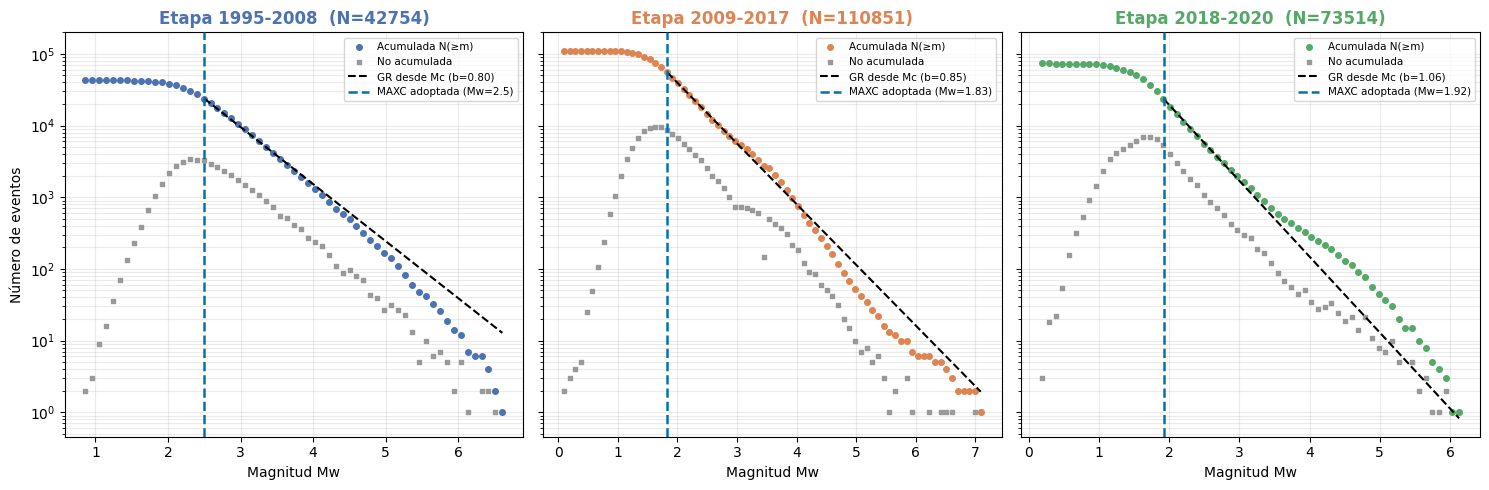

In [35]:
import matplotlib.pyplot as plt

def fmd(m):
    bins = np.round(np.arange(m.min(), m.max() + DELTA_M, DELTA_M), 3)
    edges = np.append(bins, bins[-1] + DELTA_M) - DELTA_M / 2
    nc, _ = np.histogram(m, bins=edges)
    cum = nc[::-1].cumsum()[::-1]
    return bins, nc, cum

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, (nombre, a0, a1, col) in zip(axes, ETAPAS):
    m = magnitudes_etapa(a0, a1)
    mc = mc_adoptada[nombre]
    b = estimate_b(m, mc=mc, delta_m=DELTA_M)

    bins, nc, cum = fmd(m)
    ax.scatter(bins, cum, s=16, color=col, label="Acumulada N(≥m)", zorder=3)
    ax.scatter(bins, nc, s=10, color="0.6", marker="s", label="No acumulada", zorder=2)

    N_mc = cum[np.argmin(np.abs(bins - mc))]
    a_val = np.log10(N_mc) + b * mc
    xs = np.array([mc, bins.max()])
    ax.plot(xs, 10 ** (a_val - b * xs), "k--", lw=1.5, zorder=4, label=f"GR desde Mc (b={b:.2f})")
    ax.axvline(mc, color="#0072B2", ls="--", lw=1.8, zorder=4, label=f"MAXC adoptada (Mw={mc})")

    ax.set_yscale("log")
    ax.set_title(f"Etapa {nombre}  (N={len(m)})", color=col, weight="bold")
    ax.set_xlabel("Magnitud Mw")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=7.5, loc="upper right")

axes[0].set_ylabel("Número de eventos")
fig.tight_layout()
guardar_fig(fig, "fmd_gr_mc_etapas.png")
plt.show()

## Verificación por estabilidad del b-value

No se adopta una Mc solo porque un método la señale: se comprueba que sea consistente con el comportamiento del b-value. Por debajo de la verdadera Mc el catálogo está incompleto, lo que aplana la cola de magnitudes pequeñas y sesga el b-value hacia abajo; por encima de la Mc correcta el b-value se estabiliza en una meseta (Cao & Gao 2002; Woessner & Wiemer 2005). Por eso se grafica el b-value en función de la magnitud de corte para cada etapa.

La señal de una Mc correcta es que el b-value se aplane, no que valga exactamente 1: b≈1 es solo una referencia global, y regiones de subducción y zonas volcánicas como buena parte de Colombia tienen b genuinamente por debajo de 1. Las etapas 2009–2017 y 2018–2020 alcanzan su meseta justo en su Mc de MAXC, con b≈0.8–0.9 estable, mientras que 1995–2008 nunca se estabiliza (b crece monótonamente), lo que confirma que su Mc es una estimación débil, propia de la red incipiente.

[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/b_value_estabilidad.png


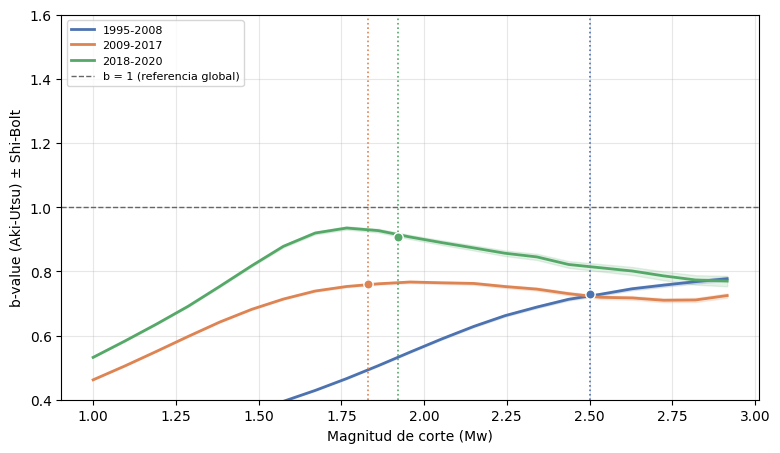

In [36]:
cortes = np.round(np.arange(1.0, 3.0 + 1e-9, DELTA_M), 3)

fig, ax = plt.subplots(figsize=(9, 5))
for nombre, a0, a1, col in ETAPAS:
    m = magnitudes_etapa(a0, a1)
    cs, bs, es = [], [], []
    for mc in cortes:
        sub = m[m >= mc - 1e-9]
        if len(sub) < 200:
            continue
        with _silencio(), warnings.catch_warnings():
            warnings.simplefilter("ignore")
            b, b_std = estimate_b(sub, mc=mc, delta_m=DELTA_M, return_std=True)
        cs.append(mc); bs.append(b); es.append(b_std)
    cs, bs, es = np.array(cs), np.array(bs), np.array(es)
    ax.plot(cs, bs, color=col, lw=2, label=nombre)
    ax.fill_between(cs, bs - es, bs + es, color=col, alpha=0.15)
    mc0 = mc_adoptada[nombre]
    ax.axvline(mc0, color=col, ls=":", lw=1.2)
    j = np.argmin(np.abs(cs - mc0))
    ax.scatter([mc0], [bs[j]], color=col, s=45, zorder=5, edgecolor="white")

ax.axhline(1.0, color="0.4", ls="--", lw=1, label="b = 1 (referencia global)")
ax.set_xlabel("Magnitud de corte (Mw)")
ax.set_ylabel("b-value (Aki-Utsu) ± Shi-Bolt")
ax.set_ylim(0.4, 1.6)
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
guardar_fig(fig, "b_value_estabilidad.png")
plt.show()

## Incertidumbre de la Mc adoptada: bootstrap del MAXC

La incertidumbre de la Mc primaria se cuantifica por bootstrap no paramétrico (Woessner & Wiemer 2005): se remuestrea el catálogo de cada etapa con reemplazo B = 300 veces, se recalcula MAXC en cada réplica y se reporta la desviación estándar de las réplicas como σ de la estimación. En las tres etapas la masa se concentra en el valor adoptado (σ ≤ 0.07, del orden de un bin de magnitud), de modo que la posición del pico del FMD, y por tanto la Mc, es robusta al remuestreo y no depende de unos pocos eventos.

[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/mc_bootstrap_etapas.png


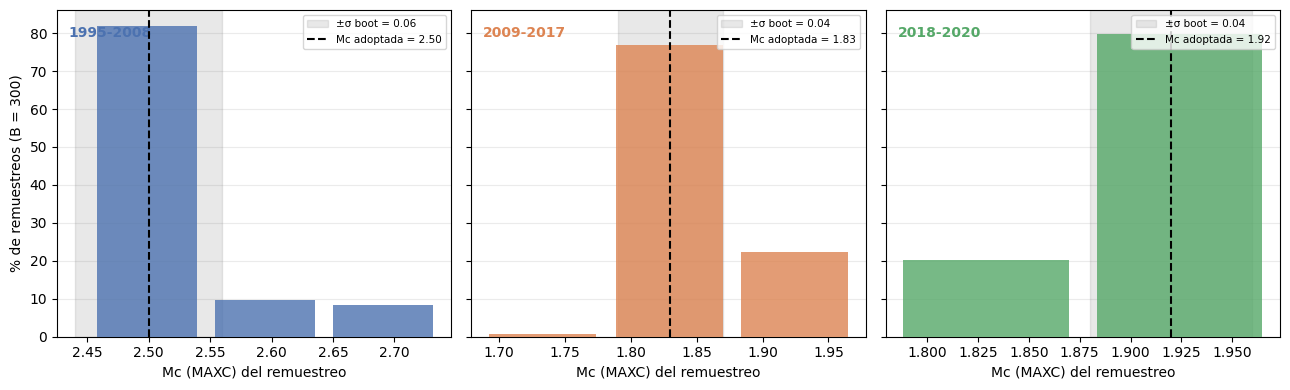

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (nombre, a0, a1, col) in zip(axes, ETAPAS):
    boot = boot_maxc[nombre]
    vals, cnts = np.unique(np.round(boot, 3), return_counts=True)
    ax.bar(vals, 100 * cnts / len(boot), width=DELTA_M * 0.85,
           color=col, alpha=0.8, zorder=3)
    mc0, s0 = mc_adoptada[nombre], sigma_maxc[nombre]
    ax.axvspan(mc0 - s0, mc0 + s0, color="0.5", alpha=0.18, zorder=2,
               label=f"±σ boot = {s0:.2f}")
    ax.axvline(mc0, color="k", ls="--", lw=1.5, zorder=4,
               label=f"Mc adoptada = {mc0:.2f}")
    ax.text(0.03, 0.95, nombre, transform=ax.transAxes, color=col,
            weight="bold", va="top")
    ax.set_xlabel("Mc (MAXC) del remuestreo")
    ax.grid(axis="y", alpha=0.25, zorder=1)
    ax.legend(fontsize=7.5, loc="upper right")
axes[0].set_ylabel(f"% de remuestreos (B = {N_BOOT})")
fig.tight_layout()
guardar_fig(fig, "mc_bootstrap_etapas.png")
plt.show()

## Filtrado por completitud: Mc de cada periodo

Se aplica a cada evento la Mc de su etapa (1995–2008 → 2.5; 2009–2017 → 1.83; 2018–2020 → 1.92), conservando así los microsismos que la red moderna sí detecta; esta opción retiene mucho más catálogo que un umbral único.

El filtro se aplica a todo el catálogo 1995–2020, no solo a 2005–2020. El periodo 1995–2004 se conserva como zona de guarda para el declustering, porque las réplicas de comienzos de 2005 necesitan encontrar su mainshock en el catálogo previo. El recorte definitivo a 2005–2020 se hace después de declusterizar.

La completitud por etapa hace que la tasa de eventos suba ~5× de 2005–2008 a 2018–2020 por mejora de detección, no por sismicidad real, y un LGCP espacio-temporal ingenuo leería ese salto como un aumento temporal de la intensidad. El modelo debe entonces incluir la etapa como efecto fijo, un intercepto por periodo que absorba el cambio de nivel debido a la detección; con ese término, el campo espacial y las covariables quedan libres del artefacto. Por eso el catálogo resultante lleva una columna `ETAPA` lista para usarse como covariable, y se reporta además el umbral único conservador (Mw ≥ `MC_LGCP`) como referencia. El modelo espacial de 2020, al no tener dimensión temporal, puede usar directamente la Mc de la etapa 2018–2020 (1.92) sin el término de etapa.

In [38]:
def etapa_de(anio):
    for nombre, a0, a1, _ in ETAPAS:
        if a0 <= anio <= a1:
            return nombre
    return None

d = df_qc.copy()
d["ETAPA"]    = d["YEAR"].map(etapa_de).astype("category")
d["MC_ETAPA"] = d["ETAPA"].map(mc_adoptada).astype(float)

df_completo = d[d["MAGNITUD_MW"] >= d["MC_ETAPA"]].reset_index(drop=True)

MC_LGCP = round(max(mc_adoptada[n] for n, a0, a1, _ in ETAPAS if a1 >= 2005), 2)

print("Mc aplicada por etapa:", mc_adoptada)
print(f"Catálogo tras QC (1995-2020):      {len(d)}")
print(f"Completos (Mc por etapa):          {len(df_completo)}  <- df_completo (con buffer 1995-2004)")
print(f"  de los cuales buffer 1995-2004:  {(df_completo['YEAR'] < 2005).sum()}")
print(f"  de los cuales 2005-2020:         {(df_completo['YEAR'] >= 2005).sum()}")
print("\nRetención por etapa (Mc por periodo):")
print(df_completo.groupby("ETAPA", observed=True).size())

df_completo[["FECHA", "YEAR", "ETAPA", "MAGNITUD_MW", "MC_ETAPA"]].head()

Mc aplicada por etapa: {'1995-2008': np.float64(2.5), '2009-2017': np.float64(1.83), '2018-2020': np.float64(1.92)}
Catálogo tras QC (1995-2020):      227119
Completos (Mc por etapa):          90541  <- df_completo (con buffer 1995-2004)
  de los cuales buffer 1995-2004:  14908
  de los cuales 2005-2020:         75633

Retención por etapa (Mc por periodo):
ETAPA
1995-2008    20501
2009-2017    46454
2018-2020    23586
dtype: int64


,FECHA,YEAR,ETAPA,MAGNITUD_MW,MC_ETAPA
0,1995-01-02 10:38:21,1995,1995-2008,3.453,2.5
1,1995-01-02 22:33:25,1995,1995-2008,4.411,2.5
2,1995-01-03 07:31:31,1995,1995-2008,3.836,2.5
3,1995-01-03 16:05:24,1995,1995-2008,2.878,2.5
4,1995-01-04 02:02:15,1995,1995-2008,2.591,2.5


[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/eventos_filtro_mc_anual.png


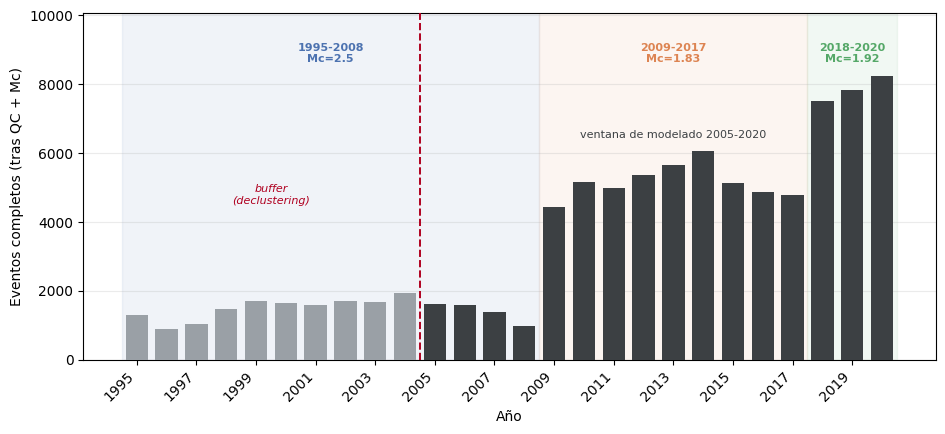

In [39]:
ev = df_completo.groupby("YEAR").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
for n, a0, a1, col in ETAPAS:
    ax.axvspan(a0 - 0.5, a1 + 0.5, color=col, alpha=0.08, zorder=0)
    ax.text((a0 + a1) / 2, ev.max() * 1.04, f"{n}\nMc={mc_adoptada[n]}",
            ha="center", va="bottom", fontsize=8, color=col, weight="bold")

colores = ["#9AA0A6" if y < 2005 else "#3C4043" for y in ev.index]
ax.bar(ev.index, ev.values, color=colores, width=0.75, zorder=3)
ax.axvline(2004.5, color="#B00020", ls="--", lw=1.4, zorder=4)
ax.text(1999.5, ev.max() * 0.55, "buffer\n(declustering)", ha="center",
        color="#B00020", fontsize=8, style="italic")
ax.text(2013, ev.max() * 0.78, "ventana de modelado 2005-2020", ha="center",
        color="#3C4043", fontsize=8)

ax.set_ylim(top=ev.max() * 1.22)
ax.set_xlabel("Año")
ax.set_ylabel("Eventos completos (tras QC + Mc)")
ax.set_xticks(range(1995, 2021, 2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25, zorder=1)
guardar_fig(fig, "eventos_filtro_mc_anual.png")
plt.show()

# Declustering (Reasenberg) y recorte espacial

Se separa la sismicidad de fondo de las réplicas y premonitorios con el algoritmo de Reasenberg (1985), vía `bruces`, con la parametrización del pipeline v2 (`rfact=20`, `xk=0.5`, `tau_min=2.5`, `tau_max=15`, `p=0.99`). Las coordenadas se proyectan a EPSG:3116 en km, como exige el algoritmo, y `xmeff` se fija en 1.83, el mínimo de las Mc por etapa, para no dejar ningún evento del catálogo por debajo del umbral efectivo.

El declustering se corre sobre todo 1995–2020, con el buffer incluido, y el recorte temporal a 2005–2020 se aplica después, para que las réplicas de comienzos de 2005 puedan enlazarse con sus mainshocks de 2004. Finalmente se recortan los puntos a la zona continental con un buffer interno de 10 km, dejando el catálogo final en EPSG:3116.

In [40]:
from bruces import Catalog
from pyproj import Transformer

cat = df_completo.sort_values("FECHA").reset_index(drop=True)

transformador = Transformer.from_crs(4326, 3116, always_xy=True)
x_m, y_m = transformador.transform(cat["LONGITUD"].values, cat["LATITUD"].values)

XMEFF = round(min(mc_adoptada.values()), 2)   # mínimo de las Mc por etapa

cat_rb = Catalog(
    origin_times=cat["FECHA"].values,
    eastings=np.asarray(x_m) / 1000.0,
    northings=np.asarray(y_m) / 1000.0,
    depths=cat["PROFUNDIDAD_KM"].values,
    magnitudes=cat["MAGNITUD_MW"].values,
)

idx_indep = cat_rb.decluster(
    algorithm="reasenberg",
    rfact=20, xmeff=XMEFF, xk=0.5, tau_min=2.5, tau_max=15.0, p=0.99,
    return_indices=True,
)
cat["ES_INDEPENDIENTE"] = False
cat.loc[np.asarray(idx_indep), "ES_INDEPENDIENTE"] = True

# el recorte temporal va después del declustering
cat_2005 = cat[cat["YEAR"].between(2005, 2020)].copy()
df_decl = cat_2005[cat_2005["ES_INDEPENDIENTE"]].reset_index(drop=True)

n = len(cat_2005)
print(f"Declustering Reasenberg (xmeff={XMEFF}) sobre {len(cat)} eventos 1995-2020")
print(f"Ventana 2005-2020: {n} eventos")
print(f"  independientes (fondo): {len(df_decl)} ({100*len(df_decl)/n:.1f}%)")
print(f"  removidos (réplicas):   {n-len(df_decl)} ({100*(n-len(df_decl))/n:.1f}%)")
print("\nIndependientes por etapa:")
print(df_decl.groupby("ETAPA", observed=True).size())

Declustering Reasenberg (xmeff=1.83) sobre 90541 eventos 1995-2020
Ventana 2005-2020: 75633 eventos
  independientes (fondo): 40984 (54.2%)
  removidos (réplicas):   34649 (45.8%)

Independientes por etapa:
ETAPA
1995-2008     3003
2009-2017    25635
2018-2020    12346
dtype: int64


[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/eventos_declustering_anual.png


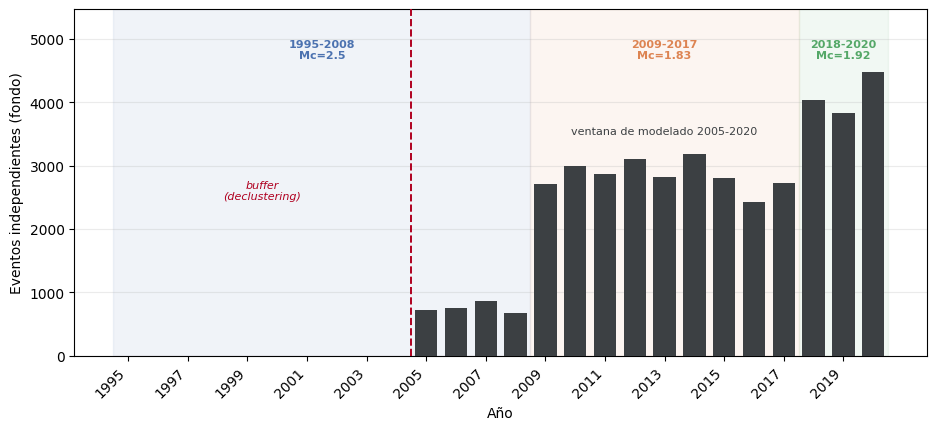

In [41]:
ev = df_decl.groupby("YEAR").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
for n, a0, a1, col in ETAPAS:
    ax.axvspan(a0 - 0.5, a1 + 0.5, color=col, alpha=0.08, zorder=0)
    ax.text((a0 + a1) / 2, ev.max() * 1.04, f"{n}\nMc={mc_adoptada[n]}",
            ha="center", va="bottom", fontsize=8, color=col, weight="bold")

colores = ["#9AA0A6" if y < 2005 else "#3C4043" for y in ev.index]
ax.bar(ev.index, ev.values, color=colores, width=0.75, zorder=3)
ax.axvline(2004.5, color="#B00020", ls="--", lw=1.4, zorder=4)
ax.text(1999.5, ev.max() * 0.55, "buffer\n(declustering)", ha="center",
        color="#B00020", fontsize=8, style="italic")
ax.text(2013, ev.max() * 0.78, "ventana de modelado 2005-2020", ha="center",
        color="#3C4043", fontsize=8)

ax.set_ylim(top=ev.max() * 1.22)
ax.set_xlabel("Año")
ax.set_ylabel("Eventos independientes (fondo)")
ax.set_xticks(range(1995, 2021, 2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25, zorder=1)
guardar_fig(fig, "eventos_declustering_anual.png")
plt.show()

[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/serie_acumulada_declustering.png


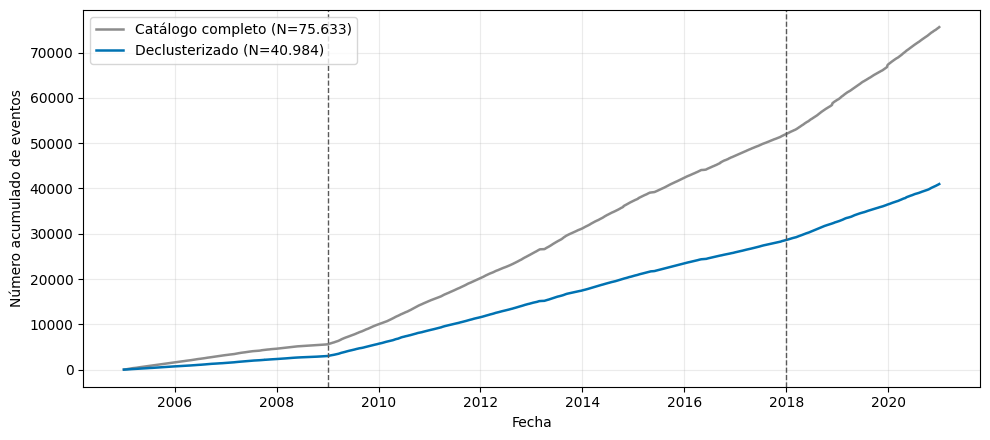

In [42]:
orden_all = cat_2005.sort_values("FECHA")
orden_dec = df_decl.sort_values("FECHA")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(orden_all["FECHA"], np.arange(1, len(orden_all) + 1),
        color="#8C8C8C", lw=1.8,
        label=f"Catálogo completo (N={len(orden_all):,})".replace(",", "."))
ax.plot(orden_dec["FECHA"], np.arange(1, len(orden_dec) + 1),
        color="#0072B2", lw=1.8,
        label=f"Declusterizado (N={len(orden_dec):,})".replace(",", "."))
for a in (pd.Timestamp("2009-01-01"), pd.Timestamp("2018-01-01")):
    ax.axvline(a, color="0.35", ls="--", lw=1)
ax.set_xlabel("Fecha")
ax.set_ylabel("Número acumulado de eventos")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
fig.tight_layout()
guardar_fig(fig, "serie_acumulada_declustering.png")
plt.show()

/tmp/ipykernel_1314529/781895870.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


[fig] /home/jasonromeroia/Documents/personal/Tesis_MCIC/MCIC_TESIS_2026_JasonRomero/images/histograma_magnitudes_declustering.png


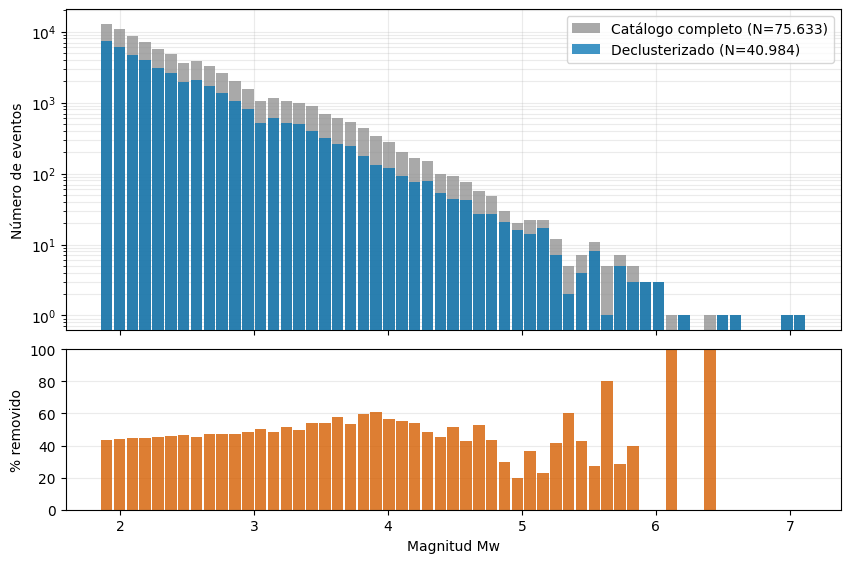

Mw [0,2): antes=12881 despues=7307 removido=43.3%
Mw [2,3): antes=53449 despues=29236 removido=45.3%
Mw [3,10): antes=9303 despues=4441 removido=52.3%


In [43]:
m_all = cat_2005["MAGNITUD_MW"].to_numpy()
m_dec = df_decl["MAGNITUD_MW"].to_numpy()
bins = np.arange(m_all.min() - DELTA_M / 2, m_all.max() + DELTA_M, DELTA_M)
n_all, _ = np.histogram(m_all, bins=bins)
n_dec, _ = np.histogram(m_dec, bins=bins)
centros = (bins[:-1] + bins[1:]) / 2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08})
ax1.bar(centros, n_all, width=DELTA_M * 0.9, color="#8C8C8C", alpha=0.75,
        label=f"Catálogo completo (N={len(m_all):,})".replace(",", "."), zorder=2)
ax1.bar(centros, n_dec, width=DELTA_M * 0.9, color="#0072B2", alpha=0.75,
        label=f"Declusterizado (N={len(m_dec):,})".replace(",", "."), zorder=3)
ax1.set_yscale("log")
ax1.set_ylabel("Número de eventos")
ax1.grid(alpha=0.25, which="both", zorder=1)
ax1.legend()

con = n_all > 0
pct = np.full(len(n_all), np.nan)
pct[con] = 100 * (n_all[con] - n_dec[con]) / n_all[con]
ax2.bar(centros, pct, width=DELTA_M * 0.9, color="#D55E00", alpha=0.8, zorder=2)
ax2.set_xlabel("Magnitud Mw")
ax2.set_ylabel("% removido")
ax2.set_ylim(0, 100)
ax2.grid(axis="y", alpha=0.25, zorder=1)
fig.tight_layout()
guardar_fig(fig, "histograma_magnitudes_declustering.png")
plt.show()

for lo, hi in [(0, 2), (2, 3), (3, 10)]:
    sel = (m_all >= lo) & (m_all < hi)
    seld = (m_dec >= lo) & (m_dec < hi)
    na, nd = sel.sum(), seld.sum()
    if na:
        print(f"Mw [{lo},{hi}): antes={na} despues={nd} removido={100*(na-nd)/na:.1f}%")

In [44]:
import geopandas as gpd

BUFFER_INTERNO_M = 10_000  # 10 km hacia adentro

ventana = gpd.read_file("/home/jasonromeroia/Documents/personal/Tesis_MCIC/lgcp_inla_spde_sismos/Data/clip_zona_continental_simplificado.geojson")
ventana_guarda = ventana.copy()
ventana_guarda["geometry"] = ventana.geometry.buffer(-BUFFER_INTERNO_M)

gdf_decl = gpd.GeoDataFrame(
    df_decl,
    geometry=gpd.points_from_xy(df_decl["LONGITUD"], df_decl["LATITUD"]),
    crs="EPSG:4326",
).to_crs(3116)

gdf_modelo = gpd.sjoin(
    gdf_decl, ventana_guarda[["geometry"]], predicate="within"
).drop(columns="index_right").reset_index(drop=True)

print(f"Declusterizados 2005-2020:        {len(gdf_decl)}")
print(f"Dentro de zona continental -10km: {len(gdf_modelo)}  <- gdf_modelo (catálogo del modelo, EPSG:3116)")
print(f"CRS: {gdf_modelo.crs}")
print("\nPor etapa:")
print(gdf_modelo.groupby('ETAPA', observed=True).size())
gdf_modelo[["FECHA","YEAR","ETAPA","MAGNITUD_MW","geometry"]].head()

Declusterizados 2005-2020:        40984
Dentro de zona continental -10km: 36545  <- gdf_modelo (catálogo del modelo, EPSG:3116)
CRS: EPSG:3116

Por etapa:
ETAPA
1995-2008     2833
2009-2017    23015
2018-2020    10697
dtype: int64


,FECHA,YEAR,ETAPA,MAGNITUD_MW,geometry
0,2005-01-01 07:29:14,2005,1995-2008,2.782,POINT (981660.729 1413694.197)
1,2005-01-01 12:44:20,2005,1995-2008,3.549,POINT (752345.952 1073625.958)
2,2005-01-01 14:41:50,2005,1995-2008,2.687,POINT (1106601.64 1254542.954)
3,2005-01-02 15:08:14,2005,1995-2008,3.357,POINT (1121879.595 1244178.65)
4,2005-01-03 04:05:55,2005,1995-2008,2.782,POINT (1102534.076 1243032.005)


# Catálogo para el modelo espacial de 2020

El modelo espacial de 2020 no tiene dimensión temporal, así que no hay que corregir el sesgo de detección entre etapas y no se necesita ni el umbral conservador de 2.5 ni el efecto fijo `ETAPA`. El año 2020 pertenece por completo a la etapa 2018–2020, cuya Mc es 1.92, que es exactamente la Mc con la que `gdf_modelo` ya filtró esos años.

Como el declustering se corrió sobre todo el catálogo 1995–2020, las réplicas de 2020 (incluidas las de mainshocks de 2019) ya están removidas. El catálogo del modelo espacial es entonces el subconjunto `YEAR == 2020` de `gdf_modelo`: sismicidad de fondo, completa a Mw ≥ 1.92, recortada a la zona continental con guarda de 10 km, en EPSG:3116.

In [45]:
gdf_espacial_2020 = gdf_modelo[gdf_modelo["YEAR"] == 2020].reset_index(drop=True)

print(f"Catálogo espacial 2020: {len(gdf_espacial_2020)} eventos de fondo (Mw >= {mc_adoptada['2018-2020']})")
print(f"CRS: {gdf_espacial_2020.crs} | rango Mw: "
      f"{gdf_espacial_2020['MAGNITUD_MW'].min():.2f}-{gdf_espacial_2020['MAGNITUD_MW'].max():.2f}")
gdf_espacial_2020[["FECHA", "MAGNITUD_MW", "geometry"]].head()

Catálogo espacial 2020: 3920 eventos de fondo (Mw >= 1.92)
CRS: EPSG:3116 | rango Mw: 1.92-5.80


,FECHA,MAGNITUD_MW,geometry
0,2020-01-01 03:48:32,2.878,POINT (1001493.684 1225681.899)
1,2020-01-01 04:17:55,2.112,POINT (1210718.248 1802767.704)
2,2020-01-01 05:25:08,2.208,POINT (1059001.693 1219741.565)
3,2020-01-01 06:58:44,2.399,POINT (760438.733 924316.556)
4,2020-01-01 20:18:11,1.920,POINT (925188.097 910547.477)


In [46]:
gdf_espacial_2020.shape

(3920, 24)

In [47]:
gdf_espacial_2020.to_file(
	"/home/jasonromeroia/Documents/personal/Tesis_MCIC/lgcp_inla_spde_sismos/Data/gdf_espacial_2020.gpkg",
	driver="GPKG"
)

In [48]:
gdf_modelo.to_file(
	"/home/jasonromeroia/Documents/personal/Tesis_MCIC/lgcp_inla_spde_sismos/Data/gdf_espacial_2005_2020.gpkg",
	driver="GPKG"
)